# Una memoria hecha de UN electrón

Un electrón. Ese es todo el hardware que necesita esta memoria para guardar un bit. No mil, no cien: uno solo, atrapado en un espacio diminuto.

Suena imposible, porque al encoger un dispositivo de memoria la propia física empieza a jugar en contra: los bordes del aparato "ahogan" la señal del electrón. Y aun así, un equipo lo consiguió. Añadir o quitar **un** electrón desplaza el voltaje umbral de la memoria medio voltio (~0,5 V)... y ahí se queda.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** [Robust single-electron memory with quantum states manipulation](https://doi.org/10.1126/science.aeg6638) · *Science, 2026*

**Datos:** [Main figure data — Figshare](https://doi.org/10.6084/m9.figshare.32483589.v1)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-18-memoria-un-electron-cuantica/notebook.ipynb)

**Video:** _(pendiente)_

## ¿Por qué es tan difícil una memoria de un electrón?

Toda memoria guarda información como carga eléctrica atrapada. El sueño de la miniaturización es llegar al límite: **un electrón = un bit**. El problema aparece justo cuando encoges el dispositivo. Al reducir el área, se dispara la *capacitancia de borde* (fringe capacitance): los campos eléctricos de los bordes empiezan a pesar más que el interior y tapan la señal del único electrón que quieres leer.

El equipo esquivó ese muro con una estructura **coplanar** — drenaje, canal y fuente sobre el mismo plano — hecha con un canal ultradelgado (material 2D). Esa geometría suprime la capacitancia de borde. Veamos qué muestran sus datos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
VTH_FISICO_UN_ELECTRON = 0.5     # Desplazamiento físico de Vth por un electrón (voltios)
AREA_MINIATURA_NM2 = 100         # Área de almacenamiento "agresiva" (nm2) donde se ve el contraste
FUENTE = 'Fuente: Liu et al. (2026), Science | Datos: Figshare'
COLOR_2D = '#2563EB'             # Canal 2D (este trabajo)
COLOR_ALERTA = '#DC2626'         # Valor de referencia / actual
COLOR_MEDIO = '#D97706'          # Bulk intermedio
COLOR_GRUESO = '#BBBBBB'         # Bulk grueso
COLOR_ANADIR = '#059669'         # Operación "añadir electrón"
COLOR_NANO = '#7C3AED'           # Bulk nanomaterial

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local -> /tmp inyectado en container -> GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Carga de los 4 datasets (Figs 1d, 2d, 3b, 3c)
senal    = pd.read_csv('datos/senal_vs_area.csv')       # Fig 1d
escalera = pd.read_csv('datos/escalera_electron.csv')   # Fig 2d
retenc   = pd.read_csv('datos/retencion.csv')           # Fig 3b
bench    = pd.read_csv('datos/benchmark.csv')           # Fig 3c

grosores = [float(x) for x in sorted(senal.canal_grosor_nm.unique())]
tiempos  = [float(t) for t in retenc.tiempo_retencion_s.tolist()]
print(f'senal vs area : {len(senal):>3} filas | grosores de canal: {grosores} nm')
print(f'escalera      : {len(escalera):>3} filas | operaciones: {list(escalera.operacion.unique())}')
print(f'retencion     : {len(retenc):>3} filas | tiempos: {tiempos} s')
print(f'benchmark     : {len(bench):>3} filas | tipos: {list(bench.tipo_dispositivo.unique())}')

senal vs area : 114 filas | grosores de canal: [0.7, 10.0, 20.0] nm
escalera      :  30 filas | operaciones: ['quitar', 'anadir']
retencion     :   5 filas | tiempos: [1.0, 10.0, 100.0, 1000.0, 5000.0] s
benchmark     :  21 filas | tipos: ['bulk_industrial', 'bulk_nanomaterial', 'canal_2D_este_trabajo']


## Aquí está.

Lo primero que hicieron fue encoger la memoria y ver cuánta señal cuántica sobrevivía.

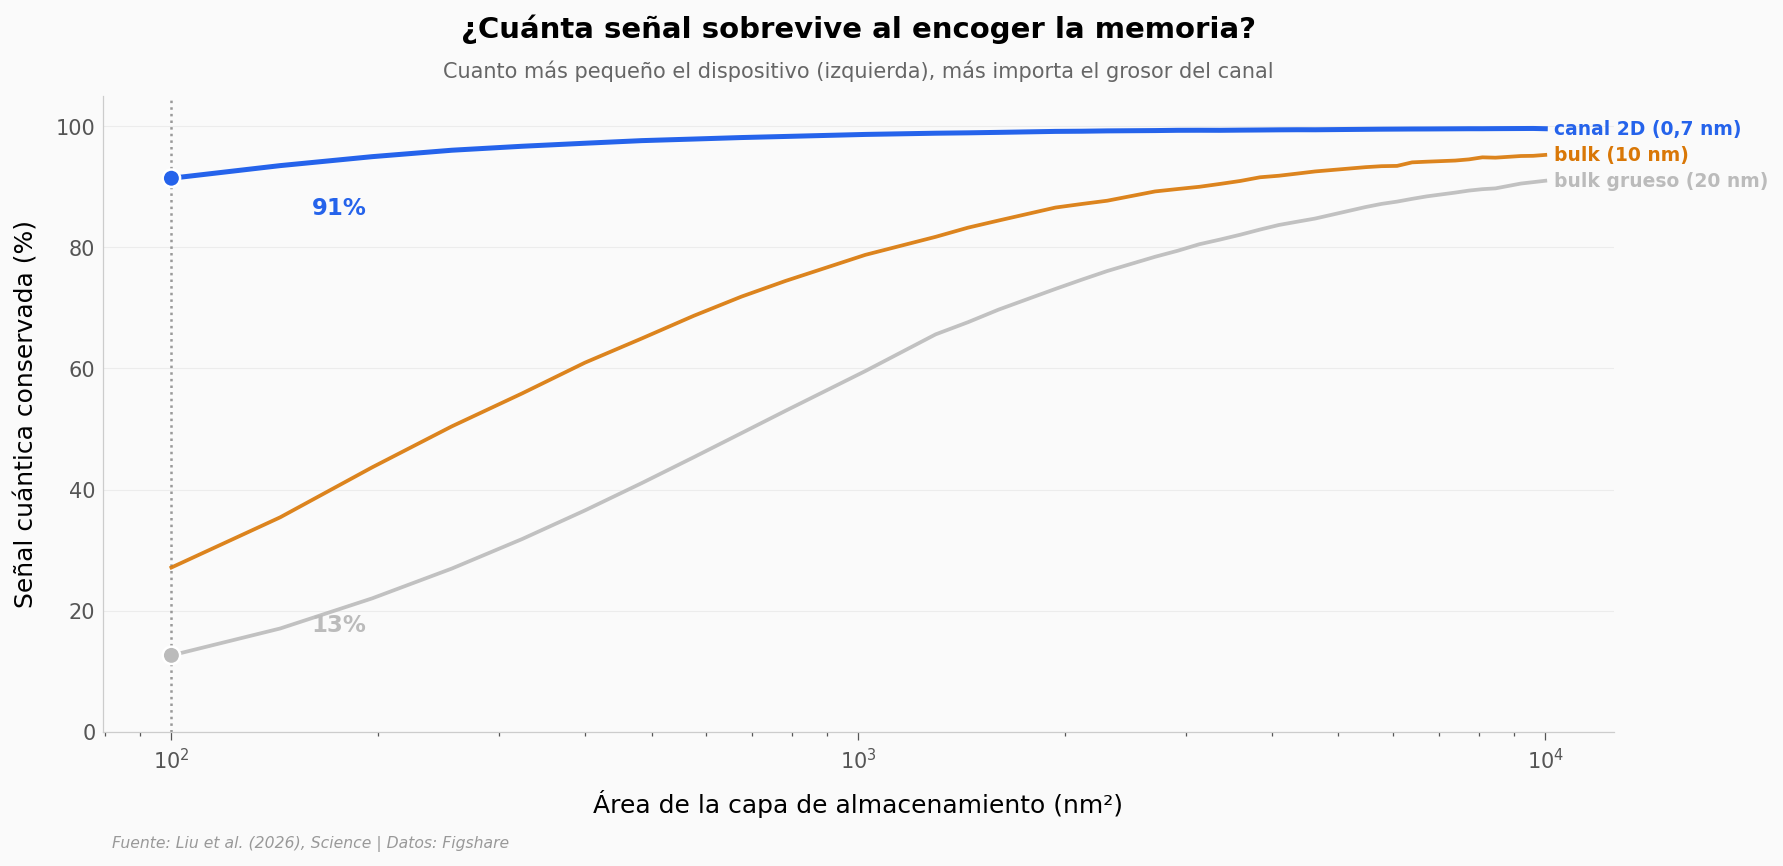

In [2]:
# Grafica hero: senal cuantica (%) vs area de almacenamiento, por grosor de canal
fig, ax = plt.subplots(figsize=(13, 5.5))

estilos = [
    (0.7, COLOR_2D,     'canal 2D (0,7 nm)',   2.4, 1.0),
    (10.0, COLOR_MEDIO, 'bulk (10 nm)',        1.8, 0.9),
    (20.0, COLOR_GRUESO,'bulk grueso (20 nm)', 1.8, 0.9),
]
for tch, color, label, lw, alpha in estilos:
    sub = senal[senal.canal_grosor_nm == tch].sort_values('area_almacen_nm2')
    ax.plot(sub.area_almacen_nm2, sub.senal_cuantica_pct, '-', color=color,
            linewidth=lw, alpha=alpha, zorder=4)
    ax.text(sub.area_almacen_nm2.iloc[-1] * 1.03, sub.senal_cuantica_pct.iloc[-1],
            label, fontsize=9, color=color, fontweight='bold', va='center')

# Marcar el area "agresiva" donde el contraste es maximo
s07 = senal[(senal.canal_grosor_nm == 0.7)  & (np.isclose(senal.area_almacen_nm2, AREA_MINIATURA_NM2))].senal_cuantica_pct.iloc[0]
s20 = senal[(senal.canal_grosor_nm == 20.0) & (np.isclose(senal.area_almacen_nm2, AREA_MINIATURA_NM2))].senal_cuantica_pct.iloc[0]
ax.axvline(AREA_MINIATURA_NM2, color='#999999', linestyle=':', linewidth=1.2, zorder=2)
ax.scatter([AREA_MINIATURA_NM2, AREA_MINIATURA_NM2], [s07, s20],
           color=[COLOR_2D, COLOR_GRUESO], s=70, edgecolors='white', linewidths=1.2, zorder=6)
ax.annotate(f'{s07:.0f}%'.replace('.', ','), xy=(AREA_MINIATURA_NM2, s07), xytext=(AREA_MINIATURA_NM2*1.6, s07-6),
            fontsize=11, fontweight='bold', color=COLOR_2D)
ax.annotate(f'{s20:.0f}%'.replace('.', ','), xy=(AREA_MINIATURA_NM2, s20), xytext=(AREA_MINIATURA_NM2*1.6, s20+4),
            fontsize=11, fontweight='bold', color=COLOR_GRUESO)

ax.set_xscale('log')
ax.set_xlabel('Área de la capa de almacenamiento (nm²)')
ax.set_ylabel('Señal cuántica conservada (%)')
ax.set_title('¿Cuánta señal sobrevive al encoger la memoria?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cuanto más pequeño el dispositivo (izquierda), más importa el grosor del canal',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 105)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/senal_vs_area.png', dpi=200, bbox_inches='tight')
plt.show()

En el tamaño más agresivo — un área de solo 100 nm² — el canal ultradelgado de 0,7 nm conserva **el 91% de la señal** cuántica, mientras que el canal grueso de 20 nm se queda en apenas **13%**. Unas 7 veces más señal, solo por adelgazar el canal.

Esa es la supresión de la capacitancia de borde en acción: con un canal delgado, los bordes dejan de ahogar al electrón. A la derecha, cuando el dispositivo es grande, todos los grosores rinden parecido — el problema solo aparece al miniaturizar, que es justo donde la memoria de un electrón tiene que vivir.

## Contando electrones de a uno

Que la señal sobreviva está bien. Pero, ¿de verdad se mueve **un** electrón a la vez? Si es así, al empujar el voltaje de programación el desplazamiento no debería subir suave, sino a **escalones**: un electrón, otro electrón, otro más.

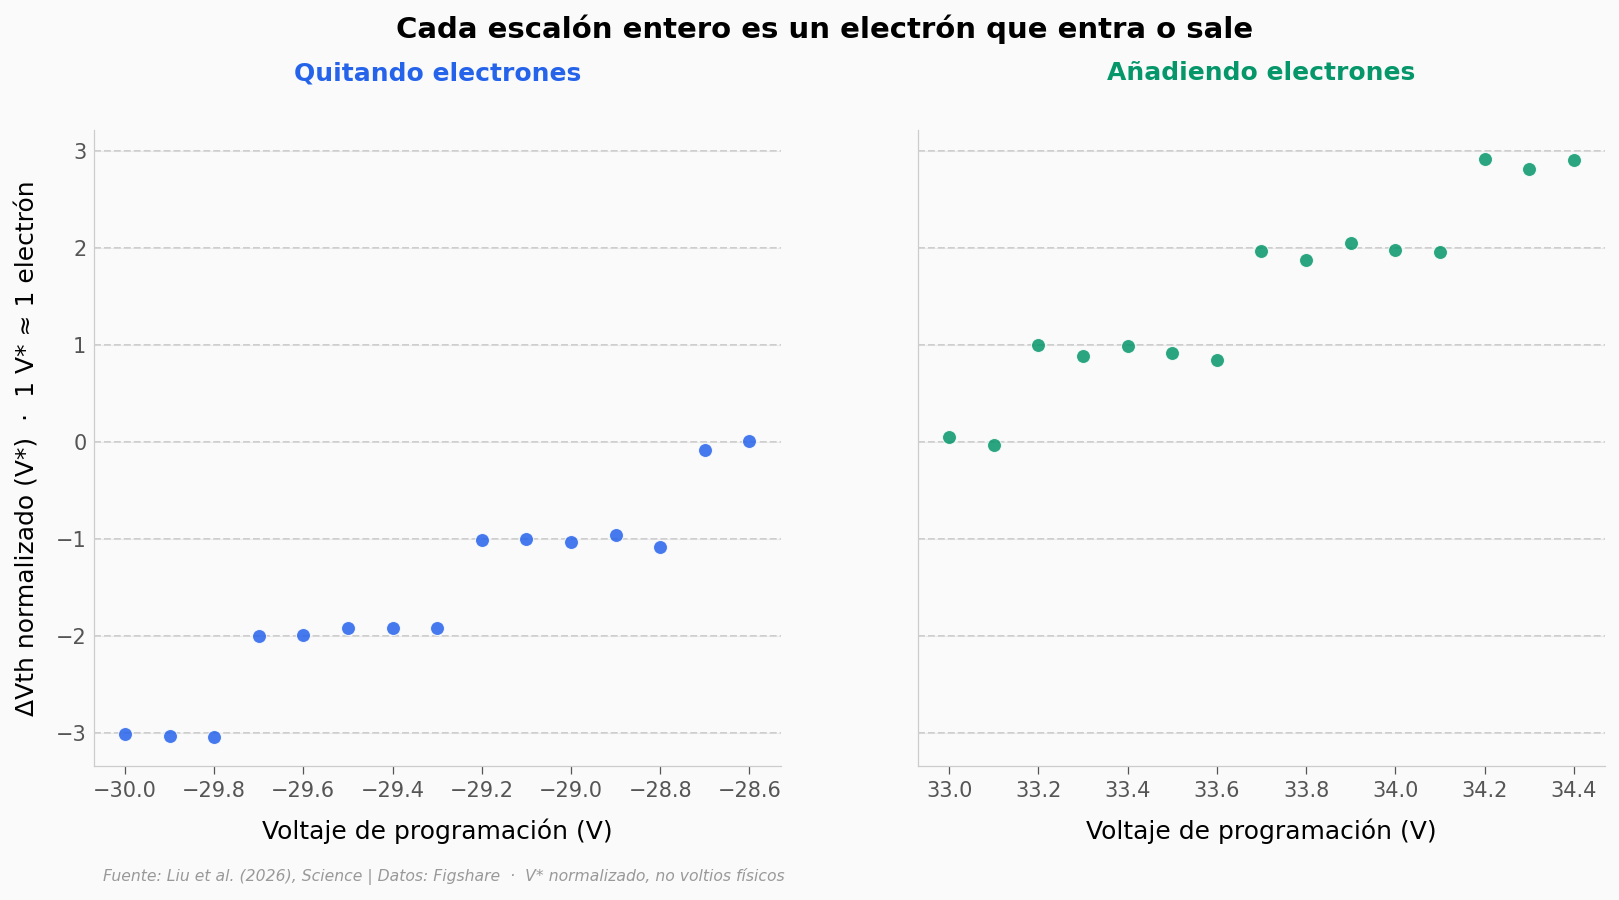

In [3]:
# Escalera cuantica: delta-Vth (normalizado en V*) vs voltaje de programacion
# V* es una unidad NORMALIZADA: 1 V* ~ el salto de un electron (NO son voltios fisicos)
fig, (axq, axa) = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

quitar = escalera[escalera.operacion == 'quitar'].sort_values('programming_vgs_v')
anadir = escalera[escalera.operacion == 'anadir'].sort_values('programming_vgs_v')

axq.scatter(quitar.programming_vgs_v, quitar.delta_vth_vstar, color=COLOR_2D,
            s=45, alpha=0.85, edgecolors='white', linewidths=0.5, zorder=5)
axa.scatter(anadir.programming_vgs_v, anadir.delta_vth_vstar, color=COLOR_ANADIR,
            s=45, alpha=0.85, edgecolors='white', linewidths=0.5, zorder=5)

# Lineas de referencia en enteros = "un electron, dos electrones..."
for nivel in range(-3, 4):
    for ax in (axq, axa):
        ax.axhline(nivel, color='#CCCCCC', linewidth=0.9, linestyle='--', zorder=1)

axq.set_title('Quitando electrones', fontsize=12, fontweight='bold', color=COLOR_2D)
axa.set_title('Añadiendo electrones', fontsize=12, fontweight='bold', color=COLOR_ANADIR)
axq.set_xlabel('Voltaje de programación (V)')
axa.set_xlabel('Voltaje de programación (V)')
axq.set_ylabel('ΔVth normalizado (V*)  ·  1 V* ≈ 1 electrón')
fig.suptitle('Cada escalón entero es un electrón que entra o sale', fontsize=14, fontweight='bold', y=1.02)
fig.text(0.13, -0.03, FUENTE + '  ·  V* normalizado, no voltios físicos', fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/escalera_electron.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Y se quedan quietos?

Contar electrones de a uno es media victoria. La otra mitad: que el estado **no se borre**. Una memoria sirve si, después de escribir, la información sigue ahí un rato largo. El equipo dejó cuatro estados distintos — con 0, 1, 2 y 3 electrones removidos — y midió su voltaje desde 1 segundo hasta 5.000 segundos.

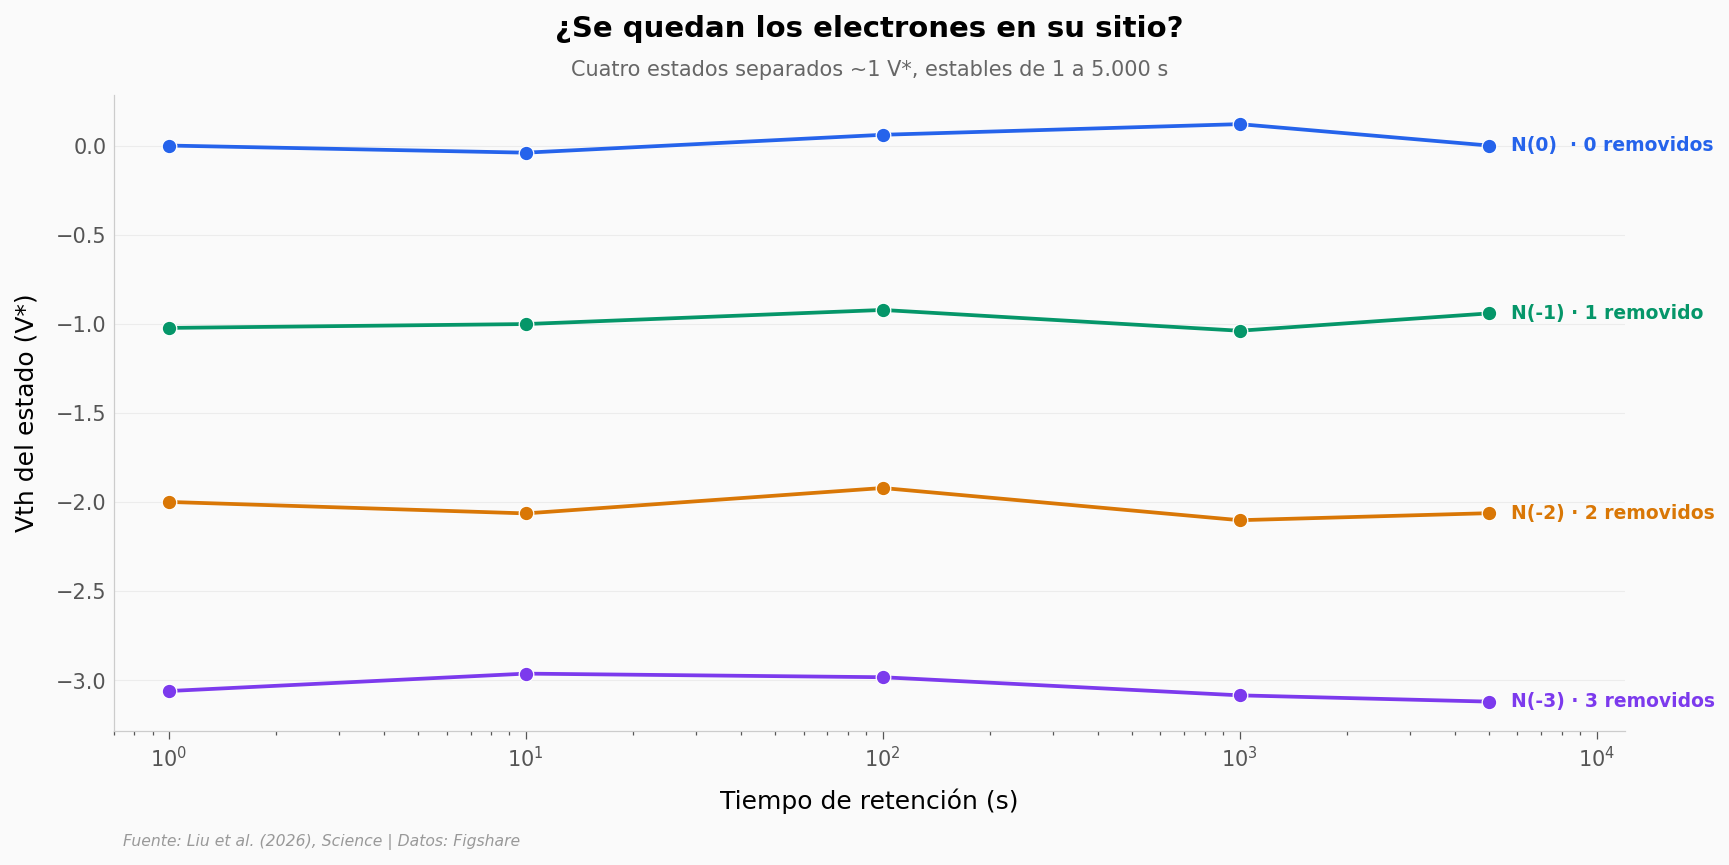

Separacion media entre estados: 1.02 V*
Ruido medio (sd) por estado   : 0.063 V*
Razon separacion/ruido        : 16 : 1  -> estados nitidamente resueltos


In [4]:
# Retencion: Vth de 4 estados (V*) vs tiempo (escala log), 1 s -> 5000 s
fig, ax = plt.subplots(figsize=(13, 5.5))

estados = [
    ('vth_N0_vstar',  'N(0)  · 0 removidos',  COLOR_2D),
    ('vth_Nm1_vstar', 'N(-1) · 1 removido',   COLOR_ANADIR),
    ('vth_Nm2_vstar', 'N(-2) · 2 removidos',  COLOR_MEDIO),
    ('vth_Nm3_vstar', 'N(-3) · 3 removidos',  COLOR_NANO),
]
t = retenc.tiempo_retencion_s
for col, label, color in estados:
    ax.plot(t, retenc[col], 'o-', color=color, markersize=7, linewidth=1.8,
            markeredgecolor='white', markeredgewidth=0.6, zorder=5)
    ax.text(t.iloc[-1] * 1.15, retenc[col].iloc[-1], label, fontsize=9,
            color=color, fontweight='bold', va='center')

# Separacion entre estados vs ruido (rigor: reemplaza a Cohen's d en un estudio de dispositivo)
medias = np.array([retenc[c].mean() for c, _, _ in estados])
sd_media = np.mean([retenc[c].std(ddof=1) for c, _, _ in estados])
sep_media = np.mean(np.abs(np.diff(medias)))
razon = sep_media / sd_media

ax.set_xscale('log')
ax.set_xlabel('Tiempo de retención (s)')
ax.set_ylabel('Vth del estado (V*)')
ax.set_title('¿Se quedan los electrones en su sitio?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cuatro estados separados ~1 V*, estables de 1 a 5.000 s',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0.7, 12000)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/retencion.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Separacion media entre estados: {sep_media:.2f} V*')
print(f'Ruido medio (sd) por estado   : {sd_media:.3f} V*')
print(f'Razon separacion/ruido        : {razon:.0f} : 1  -> estados nitidamente resueltos')

## Medio voltio. ¿Es mucho?

Un desplazamiento de 0,5 V por un electrón suena abstracto. La forma honesta de medir si es grande es compararlo con lo que logran otros dispositivos de memoria al mismo juego: cuánta señal por electrón sacan según su área.

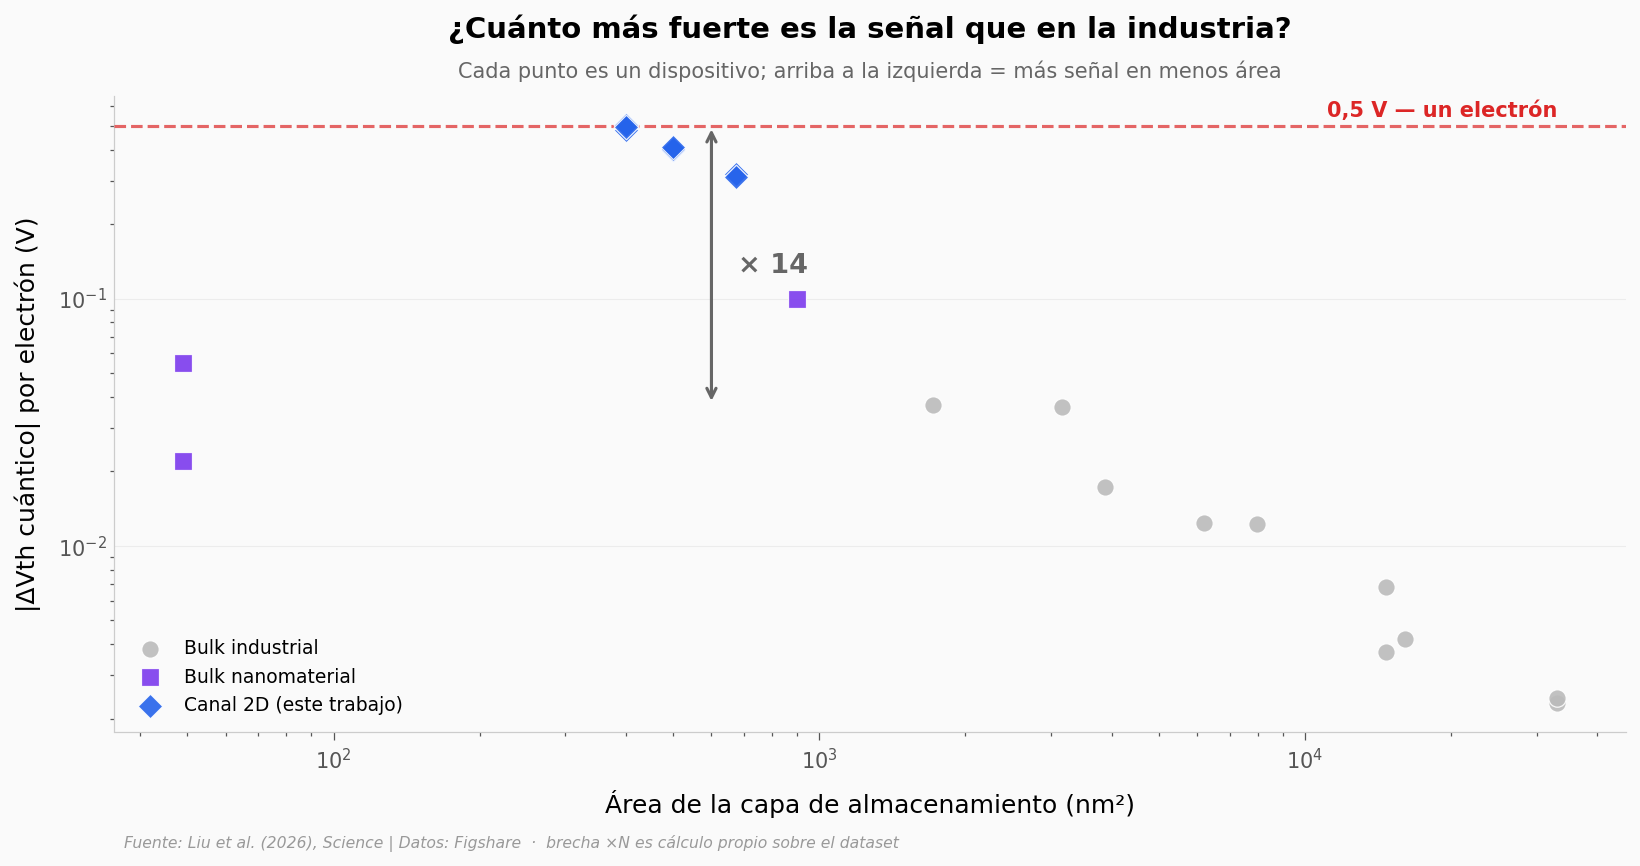

Canal 2D (max)        : 0.503 V
Bulk industrial (max) : 0.037 V
Ventaja del canal 2D  : x 13.6


In [5]:
# Benchmark: |delta-Vth cuantico| fisico (V) vs area, por familia de dispositivo
# Sirve de cierre de anomalia: el canal 2D queda muy por encima de la nube industrial
fig, ax = plt.subplots(figsize=(13, 5.5))

familias = [
    ('bulk_industrial',       'Bulk industrial',         COLOR_GRUESO, 'o'),
    ('bulk_nanomaterial',     'Bulk nanomaterial',       COLOR_NANO,   's'),
    ('canal_2D_este_trabajo', 'Canal 2D (este trabajo)', COLOR_2D,     'D'),
]
for tipo, label, color, marker in familias:
    sub = bench[bench.tipo_dispositivo == tipo]
    ax.scatter(sub.area_almacen_nm2, sub.delta_vth_quantum_v, color=color, marker=marker,
               s=70, alpha=0.9, edgecolors='white', linewidths=0.6, zorder=5, label=label)

# Referencia: 0,5 V = el shift por un electron que reporta el paper
ax.axhline(VTH_FISICO_UN_ELECTRON, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.7, zorder=3)
ax.text(bench.area_almacen_nm2.max(), VTH_FISICO_UN_ELECTRON * 1.05,
        '0,5 V — un electrón', fontsize=10, fontweight='bold', color=COLOR_ALERTA, ha='right', va='bottom')

# Cuantificar la brecha 2D vs industrial (calculo propio sobre el dataset)
max_2d  = bench[bench.tipo_dispositivo == 'canal_2D_este_trabajo'].delta_vth_quantum_v.max()
max_ind = bench[bench.tipo_dispositivo == 'bulk_industrial'].delta_vth_quantum_v.max()
ratio = max_2d / max_ind
ax.annotate('', xy=(600, max_2d), xytext=(600, max_ind),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(680, np.sqrt(max_2d * max_ind), f'× {ratio:.0f}',
        fontsize=13, fontweight='bold', color='#666666', va='center')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Área de la capa de almacenamiento (nm²)')
ax.set_ylabel('|ΔVth cuántico| por electrón (V)')
ax.set_title('¿Cuánto más fuerte es la señal que en la industria?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es un dispositivo; arriba a la izquierda = más señal en menos área',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='lower left', framealpha=0.9)
fig.text(0.13, -0.03, FUENTE + '  ·  brecha ×N es cálculo propio sobre el dataset', fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/benchmark.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Canal 2D (max)        : {max_2d:.3f} V')
print(f'Bulk industrial (max) : {max_ind:.3f} V')
print(f'Ventaja del canal 2D  : x {ratio:.1f}')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| Cambiar un electrón desplaza Vth ~0,5 V (no volátil) | ✅ | El máximo físico del canal 2D en el benchmark es 0,50 V, coincide con el 0,5 V del abstract |
| El canal 2D conserva mucha más señal al miniaturizar | ✅ | A 100 nm²: 91% (0,7 nm) vs 13% (20 nm), ~7× más señal |
| La carga entra/sale de a un electrón (escalones) | ✅ | Plateaus en múltiplos enteros de V* al quitar (0,-1,-2,-3) y añadir (0,+1,+2,+3) |
| Los estados son estables (retención) | ✅ | 4 estados separados ~1 V*, con ruido sd≈0,06 V* → separación/ruido ≈16:1, de 1 a 5.000 s |
| Señal ~14× mayor que dispositivos bulk industriales | ✅ | Cálculo propio: 0,50 V (2D) vs 0,037 V (industrial) = ×13,6 |

> **Cómo leer estos números.** V\* es una unidad **normalizada** de los datos de las escaleras: un escalón de 1 V\* equivale a un electrón, y **no** son voltios físicos. El desplazamiento físico por electrón (los 0,5 V del titular) vive en el benchmark, en voltios reales.
>
> **Limitaciones.** Es la caracterización de **un** dispositivo de laboratorio, no una línea de producción: retención medida hasta 5.000 s (no años), sin datos de resistencia a ciclos ni de variación entre chips. La ventaja de ×14 es un cálculo nuestro sobre el conjunto de benchmark, no una cifra del abstract.

## Ahora tú

1. **¿Cuánta ventaja tiene el canal 2D a otras áreas?** Cambia `AREA_MINIATURA_NM2` en la celda de configuración (prueba 144, 400, 1000) y vuelve a correr la gráfica hero. ¿A qué tamaño desaparece la ventaja?

2. **¿Qué tan nítidos son los estados de retención?** En la celda de abajo ya se calcula el ruido estado por estado. ¿Cuál de los cuatro es el más "ruidoso"?

3. **¿Y si el benchmark usara la mediana en vez del máximo?** La ventaja ×14 usa los máximos. Abajo se calcula también con las medianas. ¿Cambia mucho la historia?

In [6]:
# --- EXPERIMENTA AQUI ---
# ¿Cual estado de retencion es el mas ruidoso, y como cambia la ventaja con la mediana?

print('Ruido (sd) por estado de retencion:')
for col, label in [('vth_N0_vstar','N(0)'), ('vth_Nm1_vstar','N(-1)'),
                   ('vth_Nm2_vstar','N(-2)'), ('vth_Nm3_vstar','N(-3)')]:
    print(f'  {label:5s}: sd = {retenc[col].std(ddof=1):.3f} V*')

print()
med_2d  = bench[bench.tipo_dispositivo == 'canal_2D_este_trabajo'].delta_vth_quantum_v.median()
med_ind = bench[bench.tipo_dispositivo == 'bulk_industrial'].delta_vth_quantum_v.median()
print(f'Ventaja con MAXIMOS  : x {max_2d/max_ind:.1f}')
print(f'Ventaja con MEDIANAS : x {med_2d/med_ind:.1f}')
print('El titular usa el maximo del canal 2D: la punta mas extrema del dataset.')

Ruido (sd) por estado de retencion:
  N(0) : sd = 0.063 V*
  N(-1): sd = 0.051 V*
  N(-2): sd = 0.071 V*
  N(-3): sd = 0.067 V*

Ventaja con MAXIMOS  : x 13.6
Ventaja con MEDIANAS : x 42.6
El titular usa el maximo del canal 2D: la punta mas extrema del dataset.


## Fuentes

**Paper**: [Robust single-electron memory with quantum states manipulation](https://doi.org/10.1126/science.aeg6638)  
*Science, 2026-07-16*

**Datos**: [Main figure data (Fig 1-4) — Robust single-electron memory with quantum states manipulation](https://doi.org/10.6084/m9.figshare.32483589.v1)  
*Figshare, 2026-07-15*

*10 afirmaciones del notebook verificadas contra estas fuentes*